**Normal Equation**:- it is the magic formula which give that value of paramterts for whichloss function minimises



In [1]:
#randomly creating sort of linear data

import numpy as np
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) #(rows,colums)

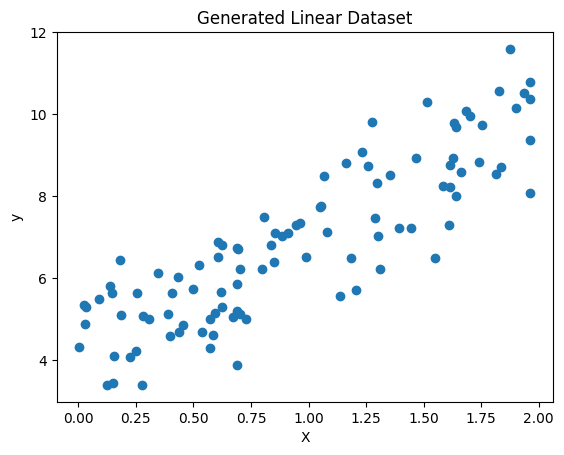

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Linear Dataset")
plt.show()

In [4]:
X_b = np.c_[np.ones((100, 1)), X]  #here c is used for concatenation for adding bias which is for all
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) #linalg stands for linear algebra

In [5]:
theta_best

array([[4.12368536],
       [2.89810678]])

we can see that it is not finding equatiomn 4+3x but it is trying to ffind weights and biases which minimises loss function

bcz

The goal of training is not to recover the true hidden equation.

The goal is to minimize the cost on the data we actually have.

Ok, lets make prediction with theta we got

In [6]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.12368536],
       [9.91989893]])

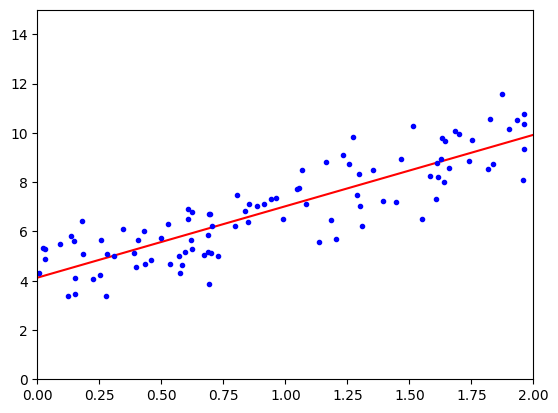

In [7]:
#plotting the model prediction

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

## now we will perform Linear Regression using Sckit learn

In [8]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.12368536]), array([[2.89810678]]))

In [9]:
lin_reg.predict(X_new)

array([[4.12368536],
       [9.91989893]])

In [10]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

#svd--> singular values decomposition

array([[4.12368536],
       [2.89810678]])

In [11]:
np.linalg.pinv(X_b).dot(y)

array([[4.12368536],
       [2.89810678]])

In [ ]:
# Normal Equation
#     ↓
# Needs matrix inverse
#     ↓
# Inverse may not exist
#     ↓
# Use Pseudoinverse instead
#     ↓
# Pseudoinverse computed using SVD
#     ↓
# SVD = Rotate → Stretch → Rotate
#     ↓
# Zero-information directions are safely ignored

## batch Gradient Descent

In [12]:
eta = 0.1  # learning rate
n_iterations = 1000
m = 100
theta = np.random.randn(2,1)  # random initialization
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

theta

array([[4.12368536],
       [2.89810678]])

## Stochastic Batch Gradient

In [13]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1) #in stochastic Batch Gradient we graduallly reduce learning rate to reduce noise

theta = np.random.randn(2,1)  # random initialization
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

theta

array([[4.15704694],
       [2.95679311]])

In [14]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [15]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.16225717]), array([2.97698855]))

# Polynomial Regression

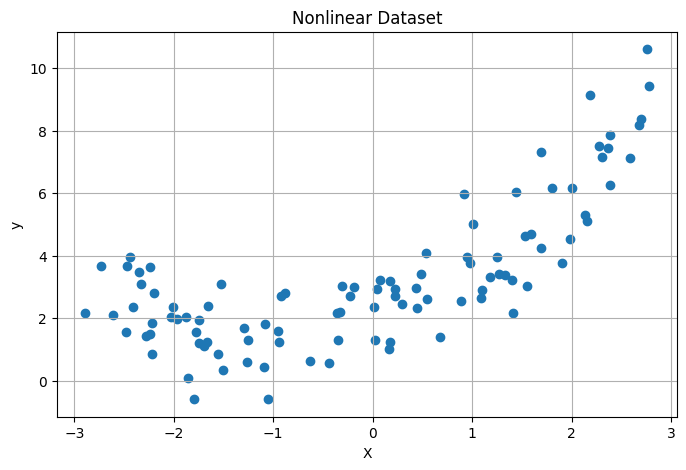

In [16]:

import numpy as np
import matplotlib.pyplot as plt

# generating non-linear data
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

# plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Nonlinear Dataset")
plt.grid(True)

plt.show()

In [ ]:
# we can make fit linear model at non linear model by squairing or doing power of features suppos x is there if we want to fit it at equation x^2 then we can do square of feature and make it fit



In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False) # since linear regression already consist of intercept so we dont need to add bias so we are doing include_bias=False
X_poly = poly_features.fit_transform(X)
X[0]

array([2.3798438])

In [18]:
X_poly[0]

array([2.3798438 , 5.66365653])

In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.98683967]), array([[1.03462169, 0.49414107]]))

Polynomial Regression is not a new learning algorithm—it's simply:

PolynomialFeatures
        +
LinearRegression

Polynomial regression can be expensive for large degree bcz it calculate for every parameter for eg for 3 degree polynomial it will calculate for4
a
b
a²
ab
b²
a³
a²b
ab²
b³
...

In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

In [ ]:
#A learning curve is a graph that shows how a model's performance changes as the amount
#of training data increases.

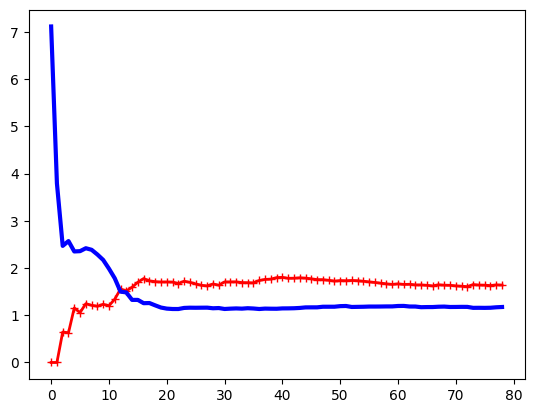

In [21]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

In [22]:
# As we add more points training error increases but after a point it will reach to plateau because now addijng more points will not cahnge in type of curve it draws
#while validation error will decrease but it will also reach to plateau because model itself has a fault and we cant decrease some of fault so it will reach to plateau.

**If your model is underfitting the training data, adding more train
ing examples will not help. You need to use a more complex model
or come up with better features.**

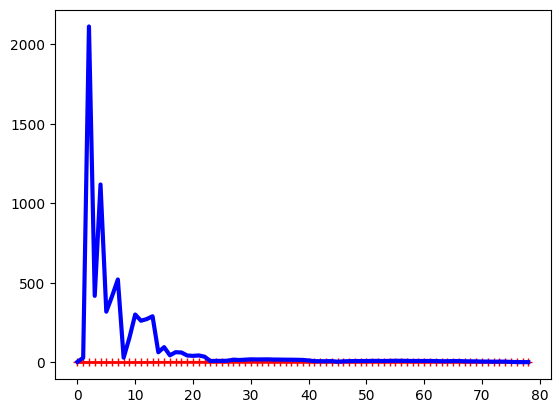

In [23]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])
plot_learning_curves(polynomial_regression, X, y)

In [ ]:
# we can see that error on training data is much lower than with the Linear regression model

# There is a gap between the curves. This means that the model performs signifi
# cantly better on the training data than on the validation data, which is the hall
# mark of an overfitting model. If you used a much larger training set, however, the
# two curves would continue to get closer.


**one way to improve an overfitting model is to feed it more training data until the validation error reaches the training error**

### **Bias:- Bias is the error caused by overly simplistic assumptions.**

## **High Variance = Overfitting**

## **The unacvoidable error is called Irreducible Error**

In [ ]:
#regularization means restricting the freedom of model.

### Ridge regression

In [24]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.82323419])

In [ ]:
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])


array([4.97706813])

## Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.93628005])

## Elastic Net Regression

In [ ]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.9401931])

## Early Stopping

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import train_test_split

# prepare the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

poly_scaler = Pipeline([
        ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
        ("std_scaler", StandardScaler())
    ])
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                        penalty=None, learning_rate="constant", eta0=0.0005)
minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

# Decision Boundary

In [26]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())


['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [28]:
X = iris["data"][:, 3:]   # Petal width only
y = (iris["target"] == 2).astype(int)   # 1 if Iris virginica, else 0

In [29]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)

LogisticRegression()

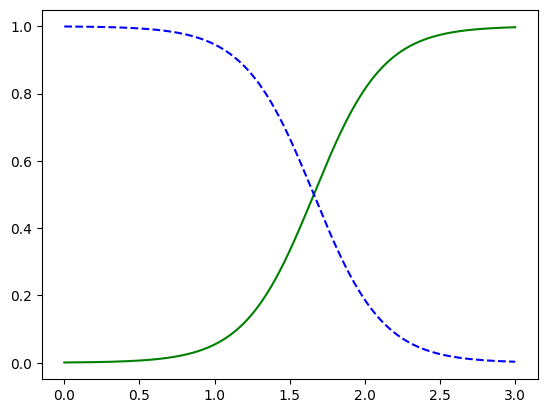

In [30]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")

this graph shows that how logistic regression creates decision boundary

and how probability of being one decreses probability of being another

As petal width increases:

Probability of Virginica increases.
Probability of Not Virginica decreases.

This creates the characteristic S-shaped sigmoid curve.

Logistic Regression does not directly output classes. It first computes a probability using a sigmoid function, then converts that probability into a class using a threshold (usually 0.5). The point where the probability equals 0.5 is called the decision boundary.

In [31]:
 log_reg.predict([[1.7], [1.5]])

array([1, 0])

# **SoftMax Regression**

In [ ]:
# Input Features
#        ↓
# Compute one score per class
#        ↓
# Setosa Score
# Versicolor Score
# Virginica Score
#        ↓
# Apply Exponential
#        ↓
# Normalize
#        ↓
# Probabilities for all classes
#        ↓
# Pick largest probability

Information Theory measures surprise.

A rare event carries more information than a common event.

In [32]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10)
softmax_reg.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, multi_class='multinomial')

In [34]:
softmax_reg.predict([[5, 2]])

array([2])

In [35]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])

For each class, compare predicted probability with the true probability. If the model gives too much probability to a class, push it down. If it gives too little probability to the correct class, push it up.